                 DESCRIPTIVE ANALYSIS

Numerical data:

Now, let's analyze the descriptive statistics for quantitative variables. In this section, we will find measurements of central tendency, dispersion, and distribution plots to compare them with the normal distribution.

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [14]:
df = pd.read_excel('../../data/raw_data.xlsx')

In [15]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [24]:
cat_columns = df.select_dtypes(include=['object']).columns.tolist()

In [16]:
def kde_plot(x):
    plt.figure(figsize=(12,3))

    sns.distplot(df[x[0]], kde_kws={'lw': 5}, hist_kws={'alpha': 0.25})
    sns.despine(left=True)

    mean = df[x[0]].mean()
    median = df[x[0]].median()

    plt.axvline(mean, color='black', linestyle='dashed')
    plt.axvline(median, color='green', linestyle='solid')
    plt.xlabel('')
    plt.ylabel('')

    return plt.show()

Now we can see the statistical interpretation for quantitative variables

C:\Users\FARUK\AppData\Local\Temp\ipykernel_1836\1919307488.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[x[0]], kde_kws={'lw': 5}, hist_kws={'alpha': 0.25})


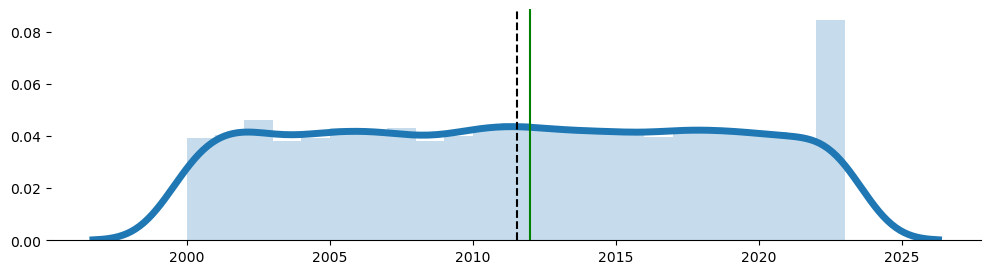

In [17]:
kde_plot([numeric_columns[0]])  #year

C:\Users\FARUK\AppData\Local\Temp\ipykernel_1836\1919307488.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[x[0]], kde_kws={'lw': 5}, hist_kws={'alpha': 0.25})


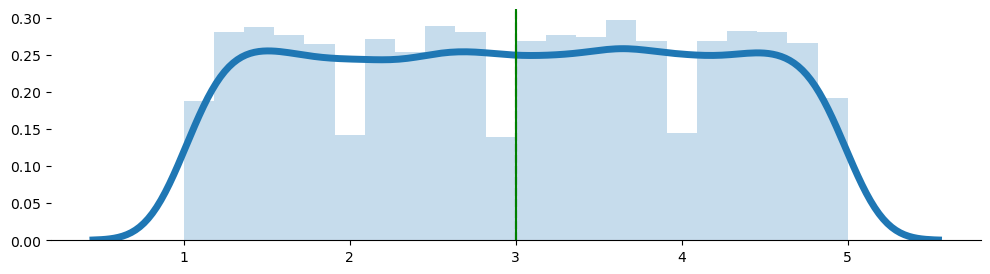

In [18]:
kde_plot([numeric_columns[1]])  #Enginesize

C:\Users\FARUK\AppData\Local\Temp\ipykernel_1836\1919307488.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[x[0]], kde_kws={'lw': 5}, hist_kws={'alpha': 0.25})


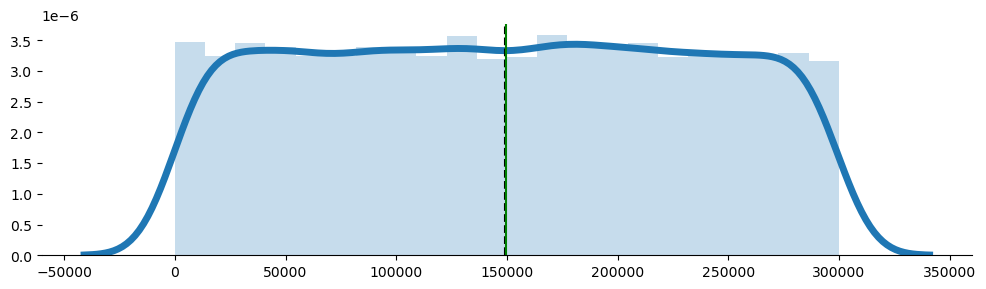

In [19]:
kde_plot([numeric_columns[2]]) #Mileage

C:\Users\FARUK\AppData\Local\Temp\ipykernel_1836\1919307488.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[x[0]], kde_kws={'lw': 5}, hist_kws={'alpha': 0.25})


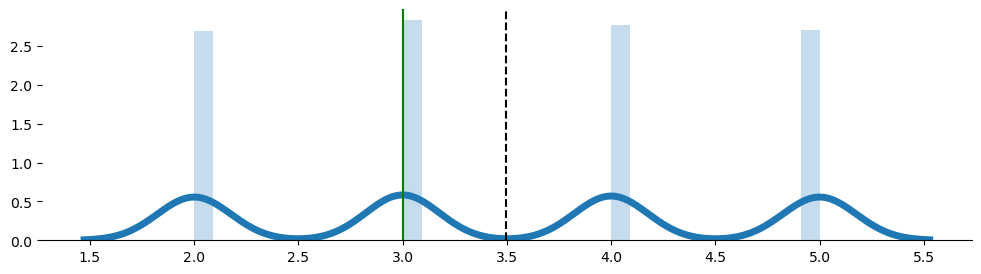

In [20]:
kde_plot([numeric_columns[3]])  #Doors

C:\Users\FARUK\AppData\Local\Temp\ipykernel_1836\1919307488.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[x[0]], kde_kws={'lw': 5}, hist_kws={'alpha': 0.25})


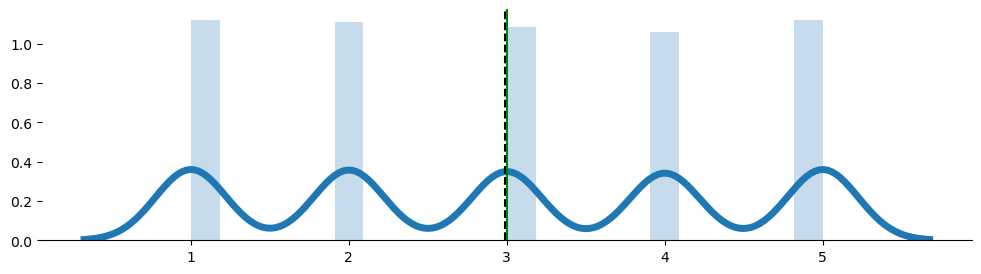

In [21]:
kde_plot([numeric_columns[4]])  #owners

C:\Users\FARUK\AppData\Local\Temp\ipykernel_1836\1919307488.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[x[0]], kde_kws={'lw': 5}, hist_kws={'alpha': 0.25})


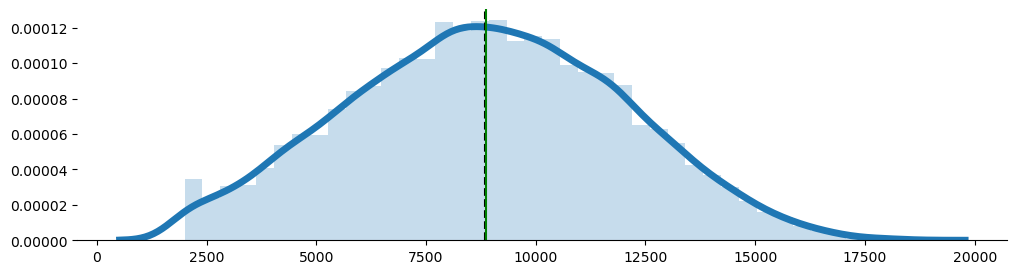

In [22]:
kde_plot([numeric_columns[5]]) #price

None of the above column does not need any transformation in later

CATEGORICAL DATA
Here, we can find the mode of categorical columns to see whuch category repeated more than rest.

In [25]:
print(cat_columns[0], '->' , df[cat_columns[0]].mode()[0])
print(cat_columns[1], '->' , df[cat_columns[1]].mode()[0])
print(cat_columns[2], '->' , df[cat_columns[2]].mode()[0])
print(cat_columns[3], '->' , df[cat_columns[3]].mode()[0])

Brand -> Ford
Model -> Accord
Fuel -> Electric
Transmission -> Manual


CORRELATION ANALYSIS

NUMERICAL DATA

 

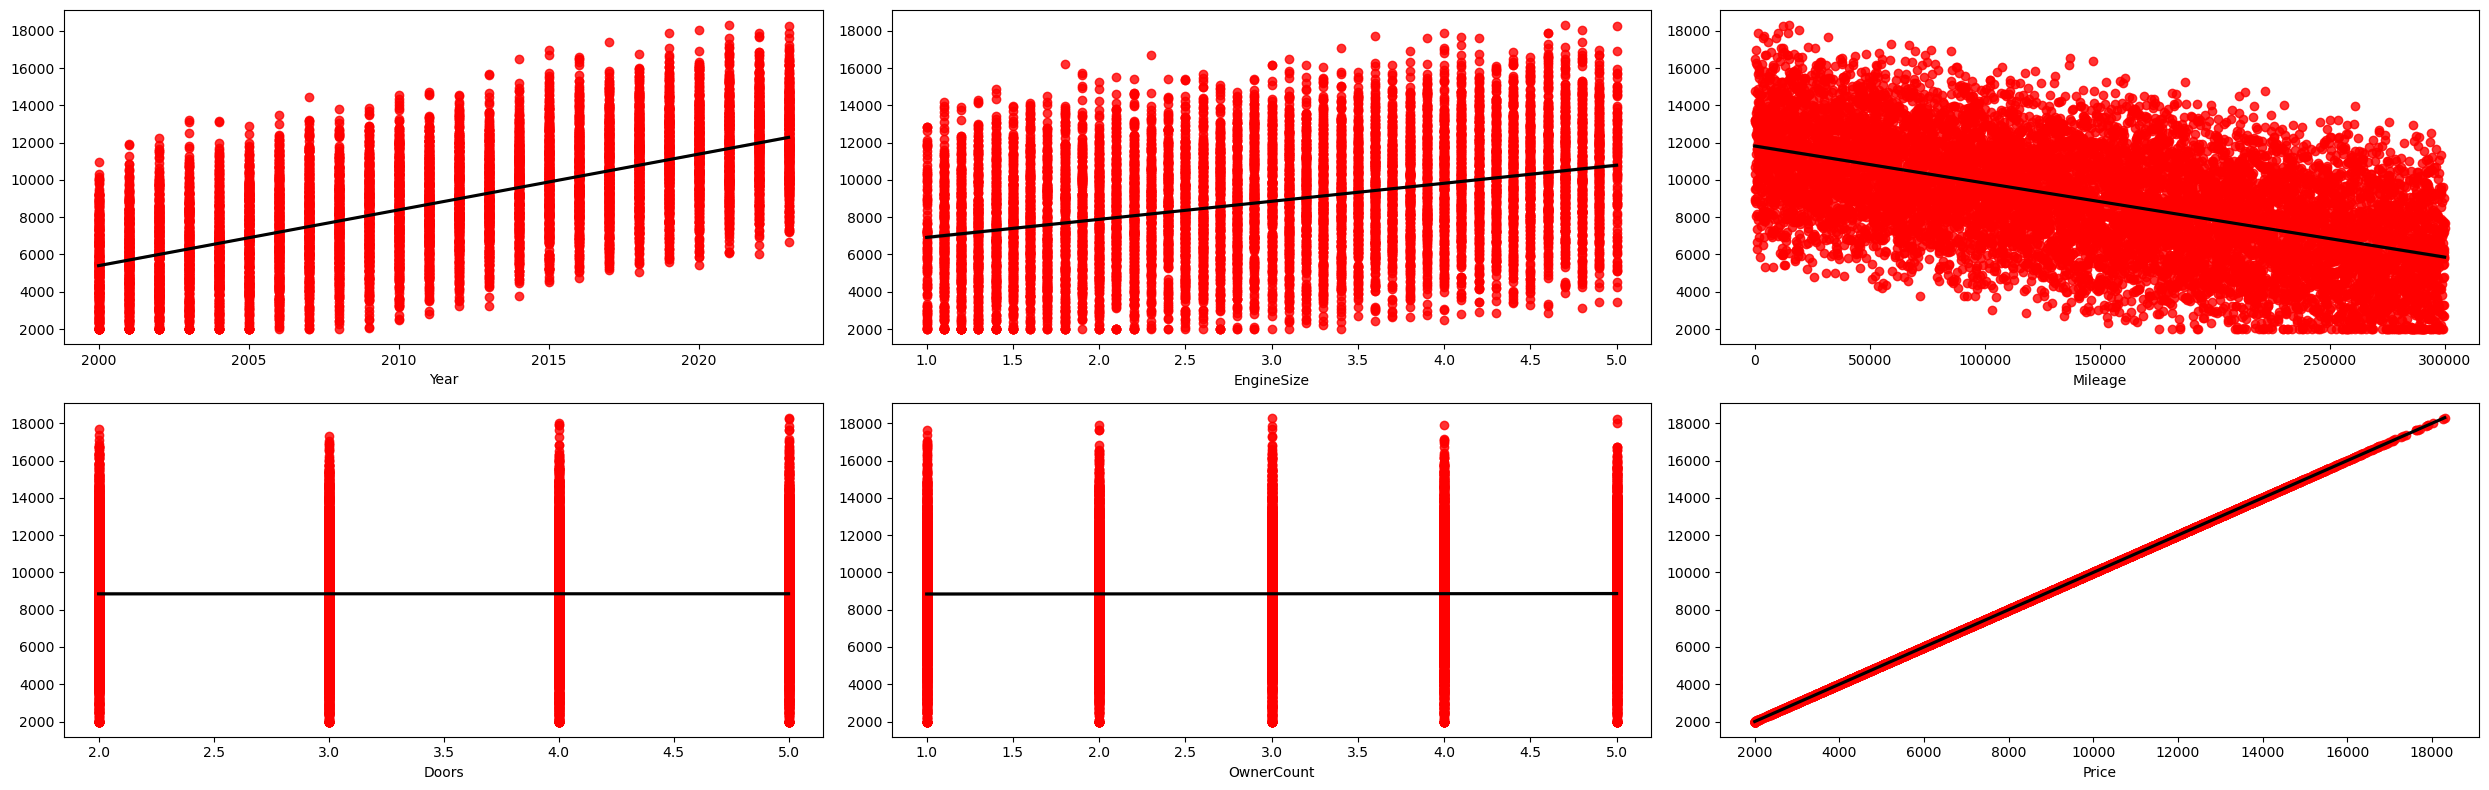

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(25, 8))
axes = axes.ravel()

for i, col in enumerate(numeric_columns):
    sns.regplot(x=col,
                y='Price',
                data=df,
                ax=axes[i],
                scatter_kws={"color":"red"},
                line_kws={"color":"black"})
    
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()


1. Numerical models have higher prices and they have a positive relationship.
2. Cars with larger engine sizes have higher prices and they also show a positive relationship.
3. Cars with smaller mileage have lower prices and they show a negative relationship.

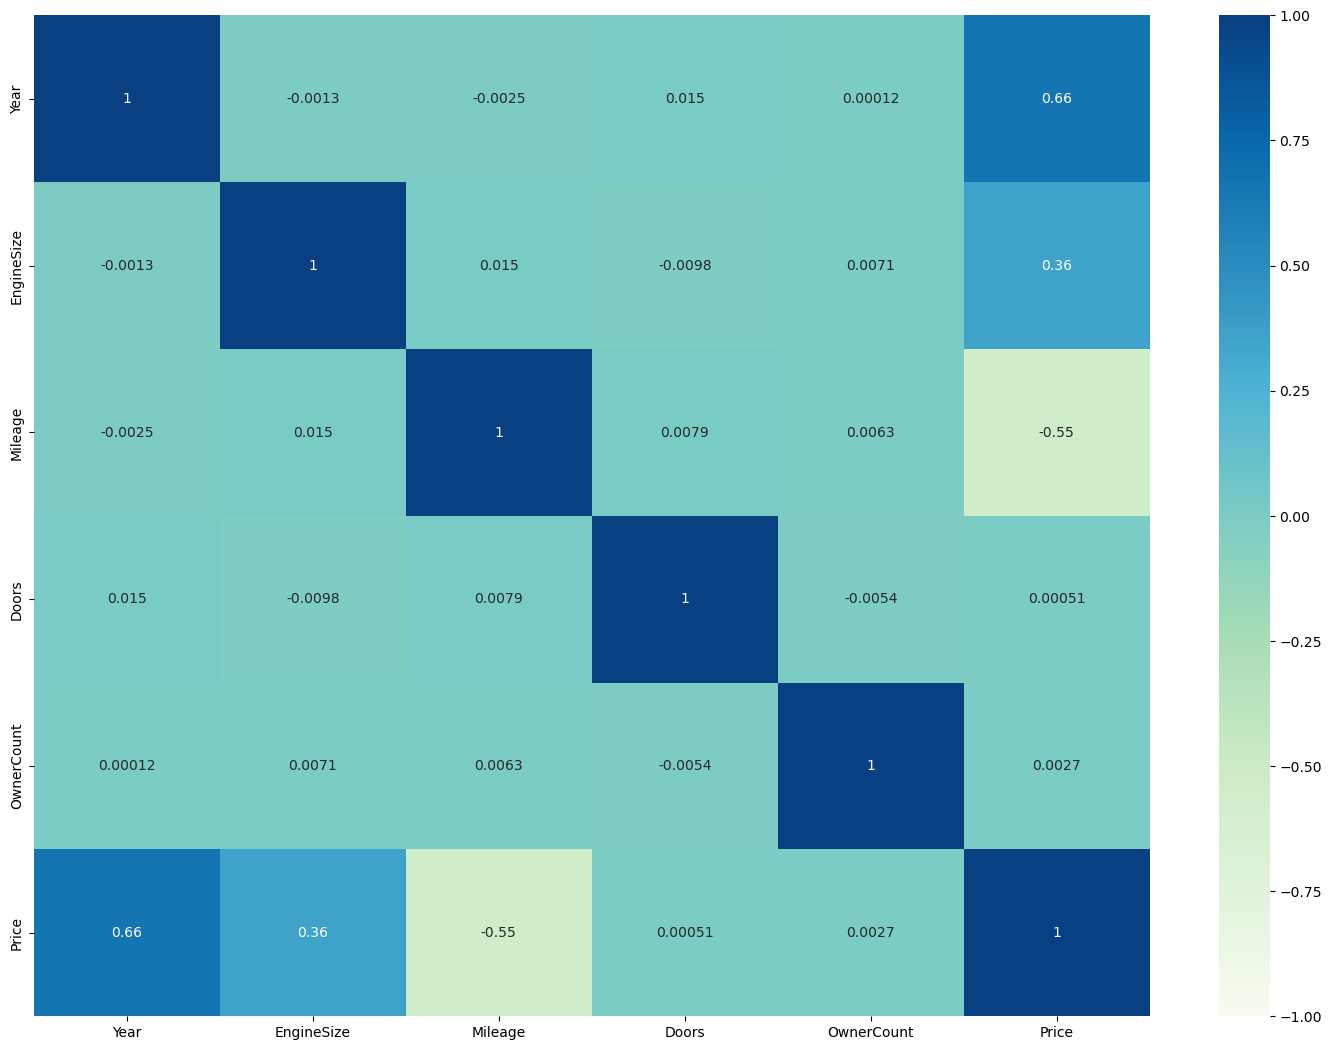

In [31]:
pearson_car = df[numeric_columns].corr(method='pearson')
plt.figure(figsize=(18,13))

sns.heatmap(
    pearson_car,
    vmin=-1,
    vmax=1,
    cmap="GnBu",
    annot=True
)

plt.show()

# For Categorical Data (ANOVA)

# For categorical variables, the first step is to determine
# whether a specific categorical variable has an impact on price.

# Meaning:
# We need to assess if the variable is statistically significant.

# To do this, we conduct an ANOVA test to compare
# the differences between means.

# After identifying significant variables,
# we perform a pairwise Tukey analysis
# for relevant categorical variables,
# allowing us to compare their effects on price.

In [34]:
for i in cat_columns:
    formula = 'Price ~ {}'.format(i)
    model = ols(formula, data=df).fit()
    anova = sm.stats.anova_lm(model, typ=2)
    p_value = anova.iloc[0, 3]

    print('P-value for Price ~ {} : {}'.format(i, p_value))

P-value for Price ~ Brand : 0.19027637004777526
P-value for Price ~ Model : 0.8177865225247054
P-value for Price ~ Fuel : 8.528045214116665e-154
P-value for Price ~ Transmission : 3.0494526820794695e-136


# According to the results, we can conclude that
# Seller and Transmission are significant in explaining
# the price of a car because the p-value is less than 0.05,
# so we reject the null hypothesis.

# However, Brand and Model might not bring
# a positive impact to our model.

# In the next step, we want to see which level
# within the categorical variables has the most impact on price.

# Thus, we create a function to calculate
# the mean price for each level variable.

# For simplicity, we return only the first five levels.

In [35]:
def mean_pairwise(cat_var):

    mean_by = df.groupby(cat_var)['Price'].mean()
    mean_by = pd.DataFrame(mean_by)
    mean_by = mean_by.sort_values(
        by=['Price'],
        inplace=False,
        ascending=True
    )

    return mean_by.head(5)

In [37]:
mean_pairwise(cat_columns[0]) #Brand

,Price
Brand,
Honda,8665.596630
BMW,8704.068068
Hyundai,8778.279397
Toyota,8798.184536
Ford,8852.570611


In [38]:
mean_pairwise(cat_columns[1]) #model

,Price
Model,
Civic,8517.327381
X5,8581.311897
5 Series,8669.218130
RAV4,8684.108025
Camry,8712.420561


In [39]:
mean_pairwise(cat_columns[2]) #fuel

,Price
Fuel,
Petrol,8070.561826
Diesel,8117.336385
Hybrid,9113.030167
Electric,10032.220190


In [40]:
mean_pairwise(cat_columns[3])  #Transmission

,Price
Transmission,
Semi-Automatic,8264.266385
Manual,8363.426157
Automatic,9938.252939
